<a href="https://colab.research.google.com/github/ddavila9-maker/sprint9-final-project/blob/main/Proyect_8_Validando_hip%C3%B3tesis_de_negocio_con_pruebas_estad%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
# cargar archivo
df = pd.read_csv('/content/landing_experiment.csv')

In [4]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [6]:
df['user_id'].nunique()

40000

In [7]:
# Resumen estadístico
df["date"].describe()

,date
count,40000
unique,28
top,2026-01-24
freq,1512


In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


In [9]:
# Resumen estadístico de gasto
df['gasto'].describe()

,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000


In [10]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].describe()

,converted
count,40000.00000
mean,0.14265
std,0.34972
min,0.00000
25%,0.00000
50%,0.00000
75%,0.00000
max,1.00000


In [11]:
# Explorar variables categóricas y cómo se distribuyen
cols_cat = ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']

print("\nConteo de categorías:")
for col in cols_cat:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100)  # en porcentaje


Conteo de categorías:

--- landing ---
landing
B    20018
A    19982
Name: count, dtype: int64
landing
B    50.0
A    50.0
Name: proportion, dtype: float64

--- region ---
region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: count, dtype: int64
region
Norte        27.9
Centro       24.0
Sur          20.1
Occidente    16.0
Oriente      12.0
Name: proportion, dtype: float64

--- dispositivo ---
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64
dispositivo
Mobile     62.1
Desktop    37.9
Name: proportion, dtype: float64

--- traffic_source ---
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64
traffic_source
Organic     45.0
Ads         29.8
Email       15.3
Referral     9.9
Name: proportion, dtype: float64

--- user_type ---
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64
user_type
Nuevo         65.1
Recurrente    34.9
Nam

In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
# Gasto por versión
gasto_A = df[(df['landing']== 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing']== 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [14]:
# Aplicar prueba
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(gasto_B, gasto_A)  # equal_var=True por defecto

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

Estadístico t: 9.36563589591332
Valor p: 1.0635288333792346e-20


In [15]:
alpha = 0.05
print(f"Gasto promedio A: {gasto_A.mean():.2f} | B: {gasto_B.mean():.2f}")
print(f"Diferencia (B - A): {gasto_B.mean() - gasto_A.mean():.2f}")

if p_value < alpha:
    print("Se rechaza H0: hay diferencia significativa en el gasto promedio.")
else:
    print("No se rechaza H0: no hay evidencia de diferencia en el gasto promedio.")

Gasto promedio A: 61.09 | B: 68.75
Diferencia (B - A): 7.66
Se rechaza H0: hay diferencia significativa en el gasto promedio.


In [16]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['user_id'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [17]:
exitos = [convertidos['A'], convertidos['B']]
observaciones = [totales['A'], totales['B']]

In [18]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(exitos , observaciones)

# Visualizar resultados
print(f"Estadístico Z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

print(f"Tasa A: {convertidos['A'] / totales['A']:.2%}")
print(f"Tasa B: {convertidos['B'] / totales['B']:.2%}")

Estadístico Z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.
Tasa A: 12.57%
Tasa B: 15.96%


In [19]:
tabla = pd.crosstab( df["traffic_source"], df["converted"])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [20]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


In [21]:
print(pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


In [22]:
tabla2 = pd.crosstab( df["user_type"], df["converted"])
print(tabla2)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [23]:
# Aplicar prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")

# Intepretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


In [24]:
print(pd.crosstab(df['user_type'], df['converted'], normalize='index')*100)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


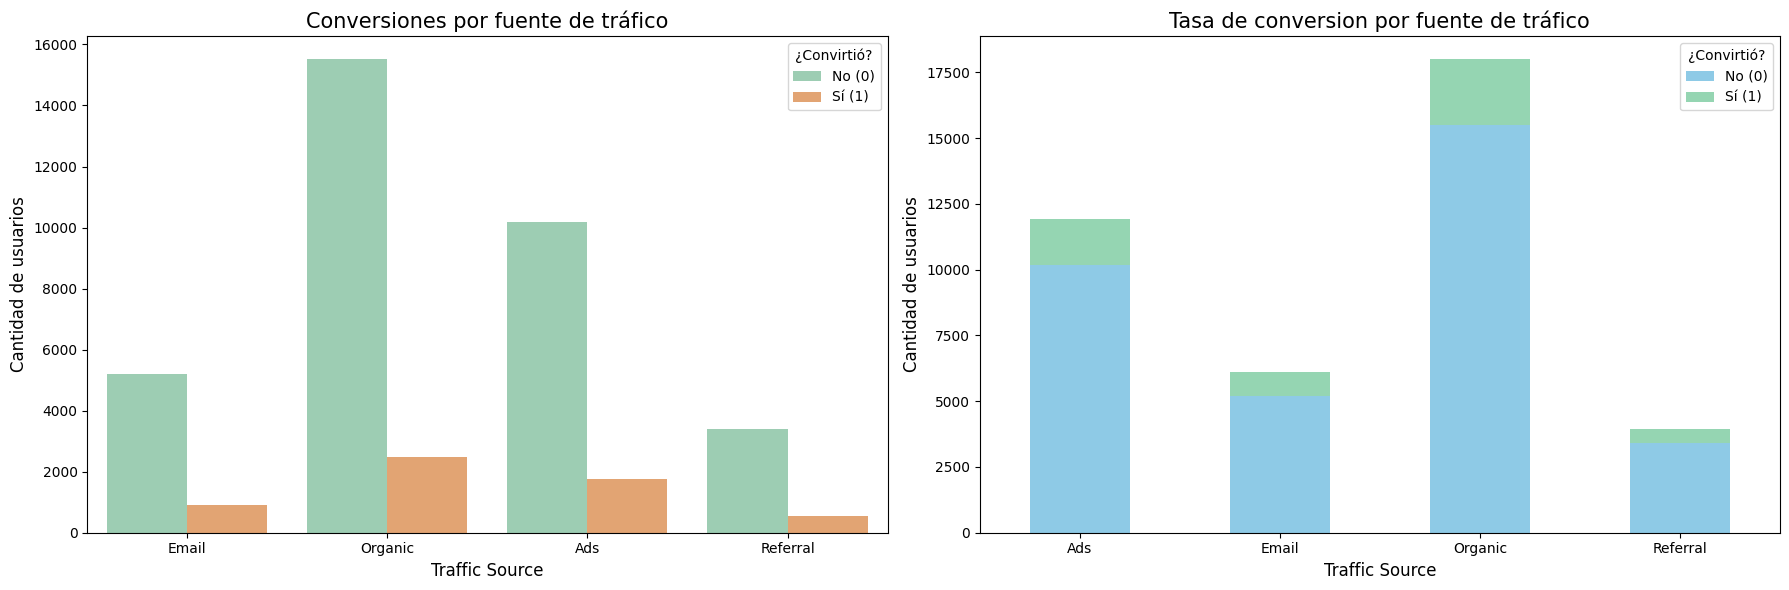

In [25]:
fig, axes= plt.subplots(1,2, figsize=(18,6))

sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por fuente de tráfico', fontsize=15)
axes[0].set_xlabel('Traffic Source', fontsize=12)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

tabla.plot(kind='bar', stacked= True, color=['#8ecae6','#95d5b2'], ax=axes[1])
axes[1].set_title('Tasa de conversion por fuente de tráfico', fontsize=15)
axes[1].set_xlabel('Traffic Source', fontsize=12)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

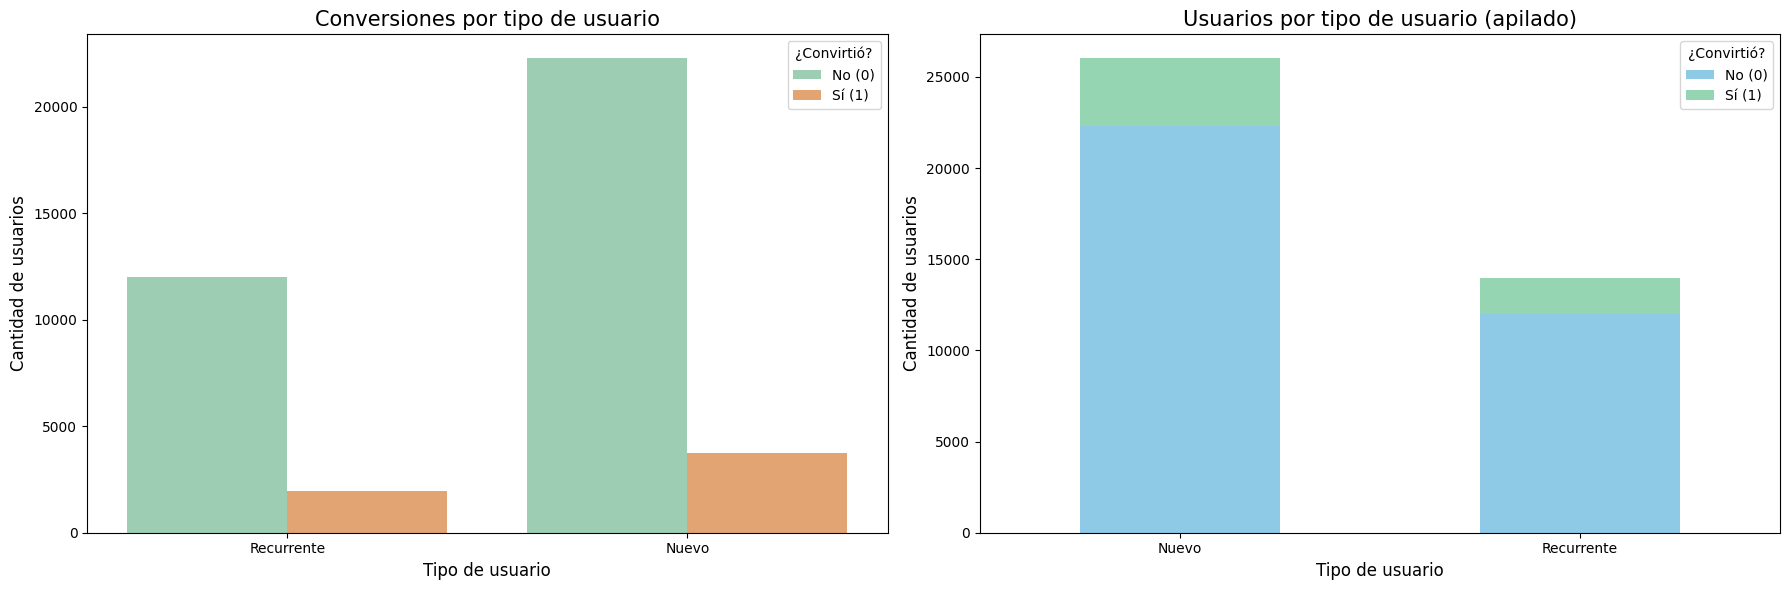

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: usuarios por tipo, según si convirtieron
sns.countplot(data=df, x='user_type', hue='converted',
              palette=["#95D5B2", "#F4A261"], ax=axes[0])
axes[0].set_title('Conversiones por tipo de usuario', fontsize=15)
axes[0].set_xlabel('Tipo de usuario', fontsize=12)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Gráfico 2: conteos apilados por tipo de usuario
tabla2.plot(kind='bar', stacked=True, color=['#8ecae6', '#95d5b2'], ax=axes[1])
axes[1].set_title('Usuarios por tipo de usuario (apilado)', fontsize=15)
axes[1].set_xlabel('Tipo de usuario', fontsize=12)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=12)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()